In [1]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [2]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Input, Dense, Reshape, Flatten, Dropout, Conv2DTranspose,
    BatchNormalization, Activation, ZeroPadding2D, LeakyReLU,
    UpSampling2D, Conv2D
)

import matplotlib.pyplot as plt
import sys

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("X_train shape:", X_train.shape)   # expect (50000, 32, 32, 3)
print("y_train shape:", y_train.shape)   # expect (50000, 1)
print("X_test  shape:", X_test.shape)    # expect (10000, 32, 32, 3)
print("dtype:", X_train.dtype)
print("pixel value range: min =", X_train.min(), ", max =", X_train.max())

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test  shape: (10000, 32, 32, 3)
dtype: uint8
pixel value range: min = 0 , max = 255


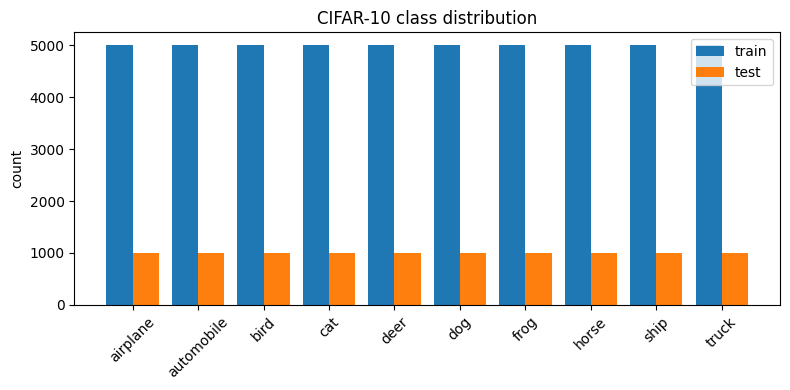

In [4]:
train_counts = np.bincount(y_train.squeeze())
test_counts = np.bincount(y_test.squeeze())

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(10)
ax.bar(x - 0.2, train_counts, width=0.4, label='train')
ax.bar(x + 0.2, test_counts, width=0.4, label='test')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45)
ax.set_ylabel("count")
ax.set_title("CIFAR-10 class distribution")
ax.legend()
plt.tight_layout()
plt.show()

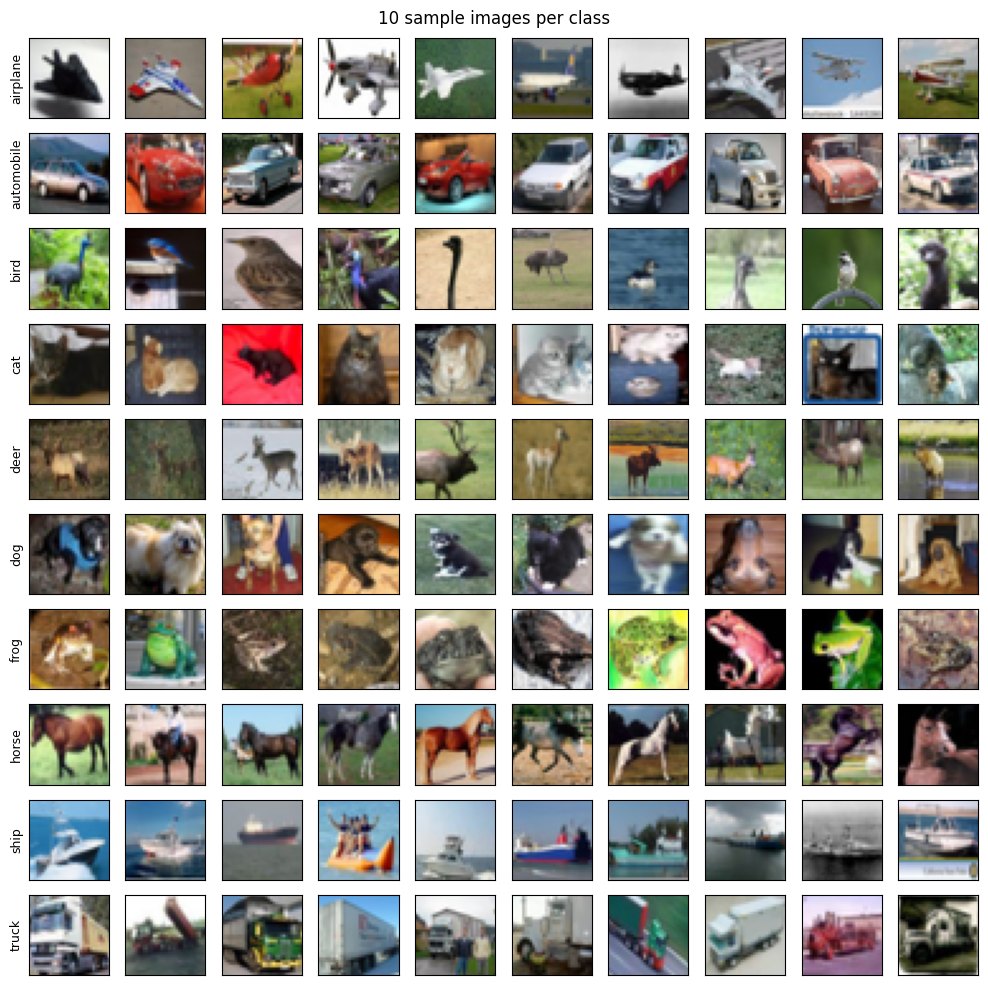

In [5]:
y_train_flat = y_train.squeeze()

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for class_idx in range(10):
    class_images = X_train[y_train_flat == class_idx]
    for i in range(10):
        ax = axes[class_idx, i]
        ax.imshow(class_images[i])
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_ylabel(class_names[class_idx], fontsize=9)

plt.suptitle("10 sample images per class")
plt.tight_layout()
plt.show()

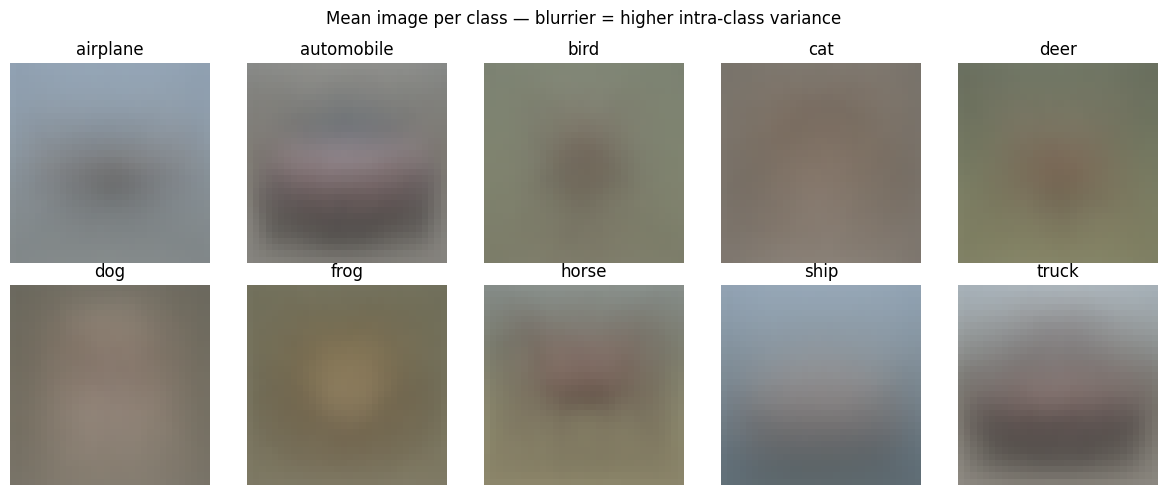

In [6]:
X_train_norm = X_train.astype("float32") / 255.0
y_train_flat = y_train.squeeze()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_idx in range(10):
    class_images = X_train_norm[y_train_flat == class_idx]
    mean_img = class_images.mean(axis=0)
    ax = axes[class_idx // 5, class_idx % 5]
    ax.imshow(mean_img)
    ax.set_title(class_names[class_idx])
    ax.axis('off')

plt.suptitle("Mean image per class — blurrier = higher intra-class variance")
plt.tight_layout()
plt.show()

In [7]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding an image."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [8]:
latent_dim = 64

encoder_inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 16, 16, 32)   896         ['input_1[0][0]']                
                                                                                                  
 conv2d_1 (Conv2D)              (None, 8, 8, 64)     18496       ['conv2d[0][0]']                 
                                                                                                  
 conv2d_2 (Conv2D)              (None, 4, 4, 128)    73856       ['conv2d_1[0][0]']               
                                                                                            

In [9]:
decoder_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(4 * 4 * 128, activation="relu")(decoder_inputs)
x = layers.Reshape((4, 4, 128))(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 64)]              0         
                                                                 
 dense_1 (Dense)             (None, 2048)              133120    
                                                                 
 reshape (Reshape)           (None, 4, 4, 128)         0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 8, 8, 128)        147584    
 nspose)                                                         
                                                                 
 conv2d_transpose_1 (Conv2DT  (None, 16, 16, 64)       73792     
 ranspose)                                                       
                                                                 
 conv2d_transpose_2 (Conv2DT  (None, 32, 32, 32)       1846

In [10]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [11]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

checkpoint_path = "cvae_cifar10_best.weights.h5"
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="loss",
    save_best_only=True,
    verbose=1
)

history = vae.fit(
    X_train_norm,
    epochs=100,
    batch_size=128,
    callbacks=[checkpoint_cb]
)

Epoch 1/150
391/391 [==============================] - ETA: 0s - loss: 685.0482 - reconstruction_loss: 660.1010 - kl_loss: 7.4061
Epoch 1: loss improved from inf to 667.50732, saving model to cvae_cifar10_best.weights.h5
391/391 [==============================] - 10s 15ms/step - loss: 685.0034 - reconstruction_loss: 660.1010 - kl_loss: 7.4061
Epoch 2/150
391/391 [==============================] - ETA: 0s - loss: 645.2799 - reconstruction_loss: 631.0809 - kl_loss: 11.4963
Epoch 2: loss improved from 667.50732 to 642.57678, saving model to cvae_cifar10_best.weights.h5
391/391 [==============================] - 6s 14ms/step - loss: 645.2730 - reconstruction_loss: 631.0809 - kl_loss: 11.4963
Epoch 3/150
388/391 [============================>.] - ETA: 0s - loss: 636.9880 - reconstruction_loss: 623.2985 - kl_loss: 12.6492
Epoch 3: loss improved from 642.57678 to 635.95569, saving model to cvae_cifar10_best.weights.h5
391/391 [==============================] - 5s 14ms/step - loss: 636.9774 - 

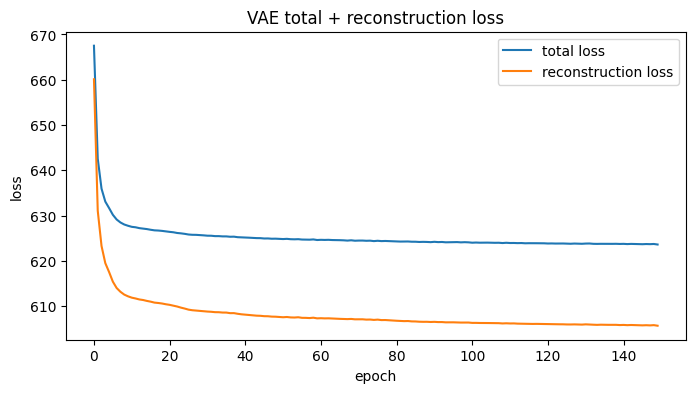

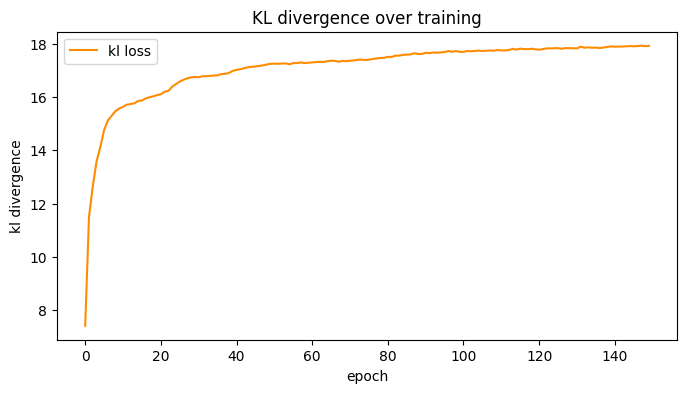

Final total loss: 623.6285
Final reconstruction loss: 605.7036
Final KL divergence: 17.9254


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='total loss')
plt.plot(history.history['reconstruction_loss'], label='reconstruction loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('VAE total + reconstruction loss')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['kl_loss'], label='kl loss', color='darkorange')
plt.xlabel('epoch')
plt.ylabel('kl divergence')
plt.legend()
plt.title('KL divergence over training')
plt.show()
final_loss = history.history['loss'][-1]
final_recon_loss = history.history['reconstruction_loss'][-1]
final_kl_loss = history.history['kl_loss'][-1]

print(f"Final total loss: {final_loss:.4f}")
print(f"Final reconstruction loss: {final_recon_loss:.4f}")
print(f"Final KL divergence: {final_kl_loss:.4f}")

1/1 [==============================] - 0s 90ms/step


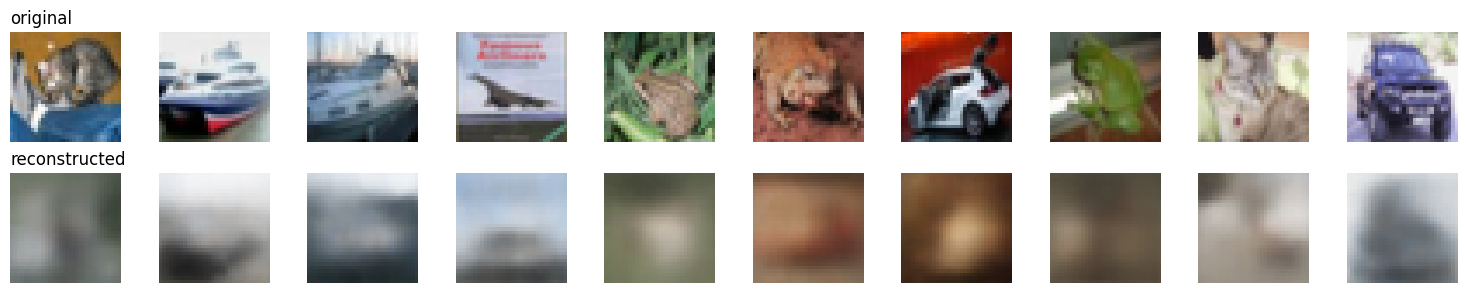

In [13]:
n = 10
sample_imgs = X_test_norm[:n]
_, _, z = vae.encoder.predict(sample_imgs)
reconstructed = vae.decoder.predict(z)

fig, axes = plt.subplots(2, n, figsize=(15, 3))
for i in range(n):
    axes[0, i].imshow(sample_imgs[i])
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i])
    axes[1, i].axis('off')
axes[0, 0].set_title("original", loc='left')
axes[1, 0].set_title("reconstructed", loc='left')
plt.tight_layout()
plt.show()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_7 (Conv2D)              (None, 16, 16, 32)   896         ['input_5[0][0]']                
                                                                                                  
 conv2d_8 (Conv2D)              (None, 8, 8, 64)     18496       ['conv2d_7[0][0]']               
                                                                                                  
 conv2d_9 (Conv2D)              (None, 4, 4, 128)    73856       ['conv2d_8[0][0]']               
                                                                                            

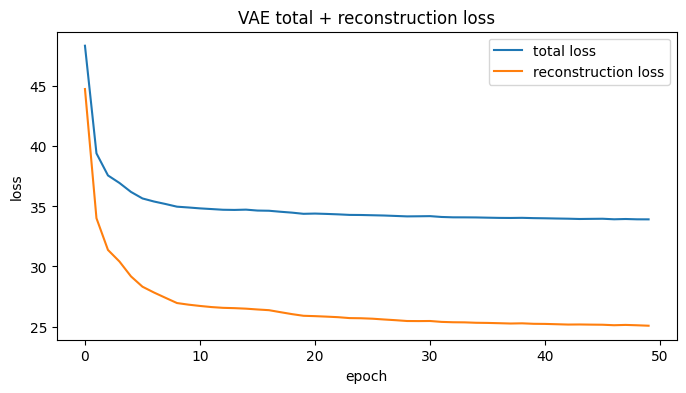

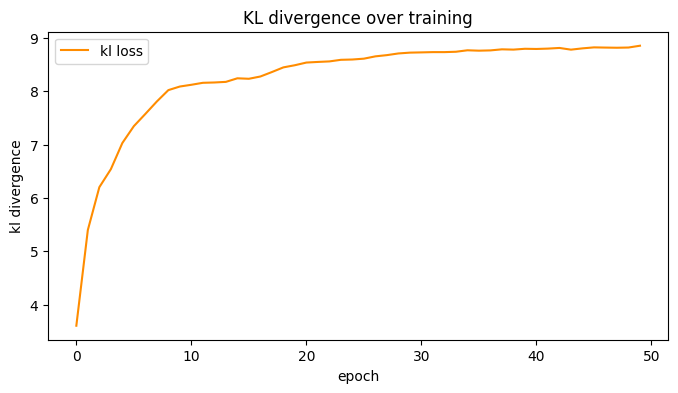

Final total loss: 33.9207
Final reconstruction loss: 25.0671
Final KL divergence: 8.8536


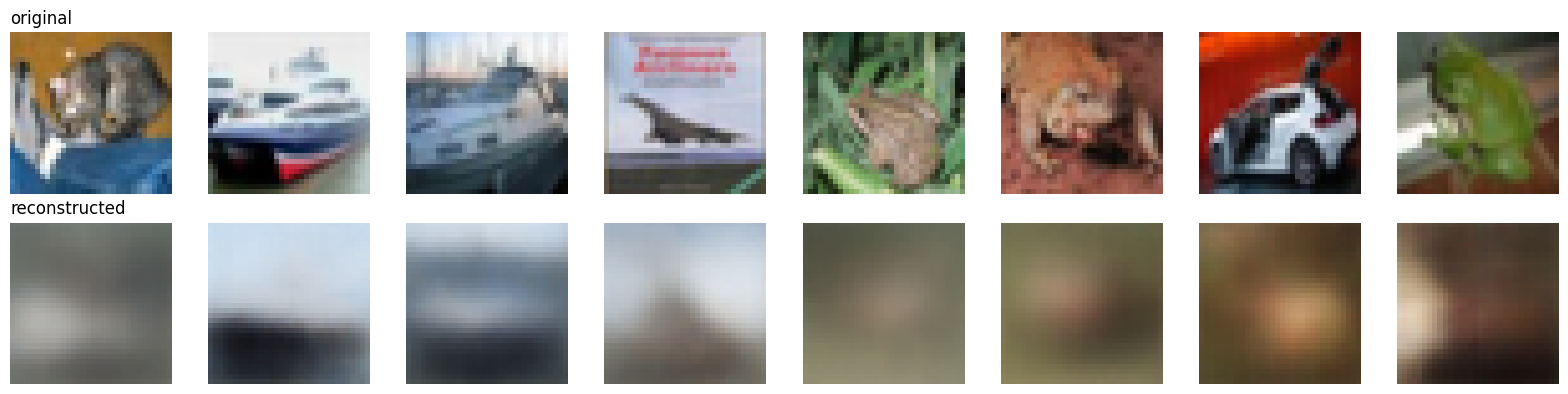

In [16]:
latent_dim = 64  # bumped up again with the deeper network

encoder_inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)   # 32 -> 16
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)                # 16 -> 8
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)               # 8 -> 4
x = layers.Conv2D(256, 3, activation="relu", strides=2, padding="same")(x)               # 4 -> 2
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

# ---------- Decoder ----------
decoder_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(2 * 2 * 256, activation="relu")(decoder_inputs)
x = layers.Reshape((2, 2, 256))(x)
x = layers.Conv2DTranspose(256, 3, activation="relu", strides=2, padding="same")(x)  # 2 -> 4
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)  # 4 -> 8
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)   # 8 -> 16
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)   # 16 -> 32
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")
decoder.summary()

# ---------- VAE model ----------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.mean_squared_error(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# ---------- Data ----------
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# ---------- Train ----------
vae = VAE(encoder, decoder)
_ = vae(X_test_norm[:1])   # build the model
vae.compile(optimizer=keras.optimizers.Adam())

checkpoint_path = "cvae_cifar10_best.weights.h5"
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="loss",
    save_best_only=True,
    verbose=1
)

history = vae.fit(
    X_train_norm,
    epochs=50,
    batch_size=128,
    callbacks=[checkpoint_cb]
)

# ---------- Curves ----------
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='total loss')
plt.plot(history.history['reconstruction_loss'], label='reconstruction loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend()
plt.title('VAE total + reconstruction loss')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['kl_loss'], label='kl loss', color='darkorange')
plt.xlabel('epoch'); plt.ylabel('kl divergence'); plt.legend()
plt.title('KL divergence over training')
plt.show()

print(f"Final total loss: {history.history['loss'][-1]:.4f}")
print(f"Final reconstruction loss: {history.history['reconstruction_loss'][-1]:.4f}")
print(f"Final KL divergence: {history.history['kl_loss'][-1]:.4f}")

# ---------- Reconstructions ----------
vae.load_weights(checkpoint_path)

n = 8
sample_imgs = X_test_norm[:n]
_, _, z = vae.encoder.predict(sample_imgs, verbose=0)
reconstructed = vae.decoder.predict(z, verbose=0)

fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
for i in range(n):
    axes[0, i].imshow(sample_imgs[i]); axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i]); axes[1, i].axis('off')
axes[0, 0].set_title("original", loc='left')
axes[1, 0].set_title("reconstructed", loc='left')
plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 18ms/step


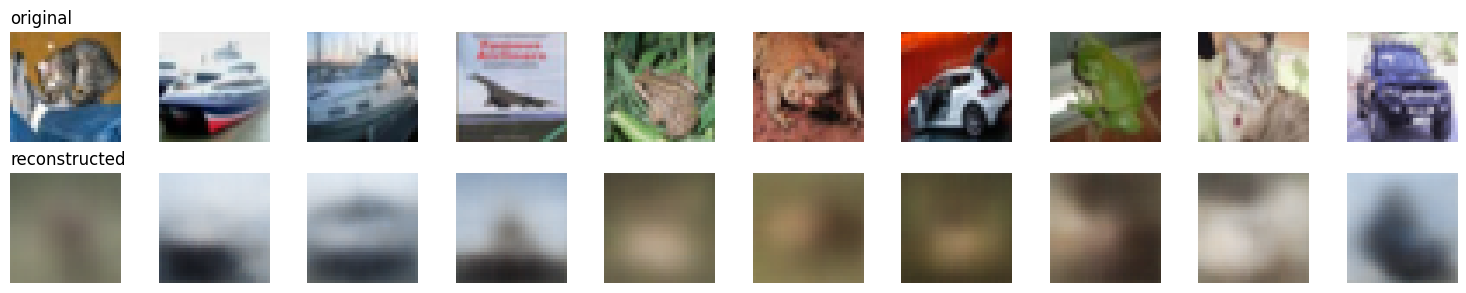

In [17]:
n = 10
sample_imgs = X_test_norm[:n]
_, _, z = vae.encoder.predict(sample_imgs)
reconstructed = vae.decoder.predict(z)

fig, axes = plt.subplots(2, n, figsize=(15, 3))
for i in range(n):
    axes[0, i].imshow(sample_imgs[i])
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i])
    axes[1, i].axis('off')
axes[0, 0].set_title("original", loc='left')
axes[1, 0].set_title("reconstructed", loc='left')
plt.tight_layout()
plt.show()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_11 (Conv2D)             (None, 16, 16, 32)   896         ['input_7[0][0]']                
                                                                                                  
 conv2d_12 (Conv2D)             (None, 8, 8, 64)     18496       ['conv2d_11[0][0]']              
                                                                                                  
 conv2d_13 (Conv2D)             (None, 4, 4, 128)    73856       ['conv2d_12[0][0]']              
                                                                                            

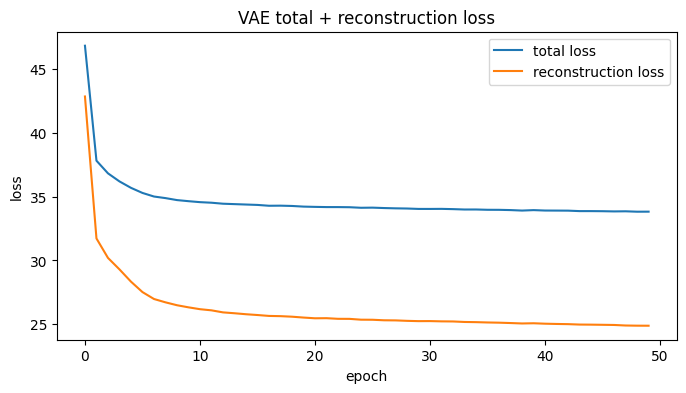

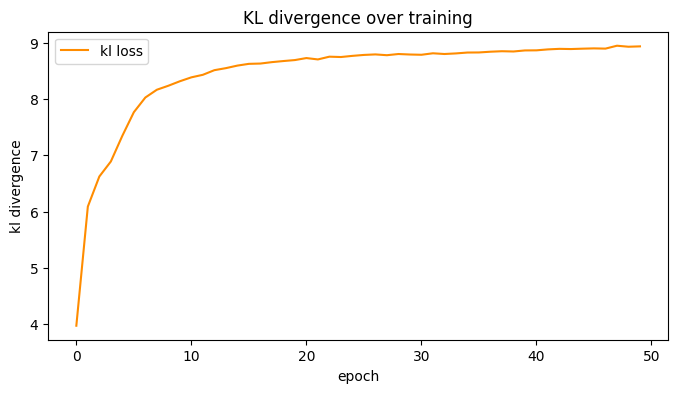

Final total loss: 33.8200
Final reconstruction loss: 24.8885
Final KL divergence: 8.9315


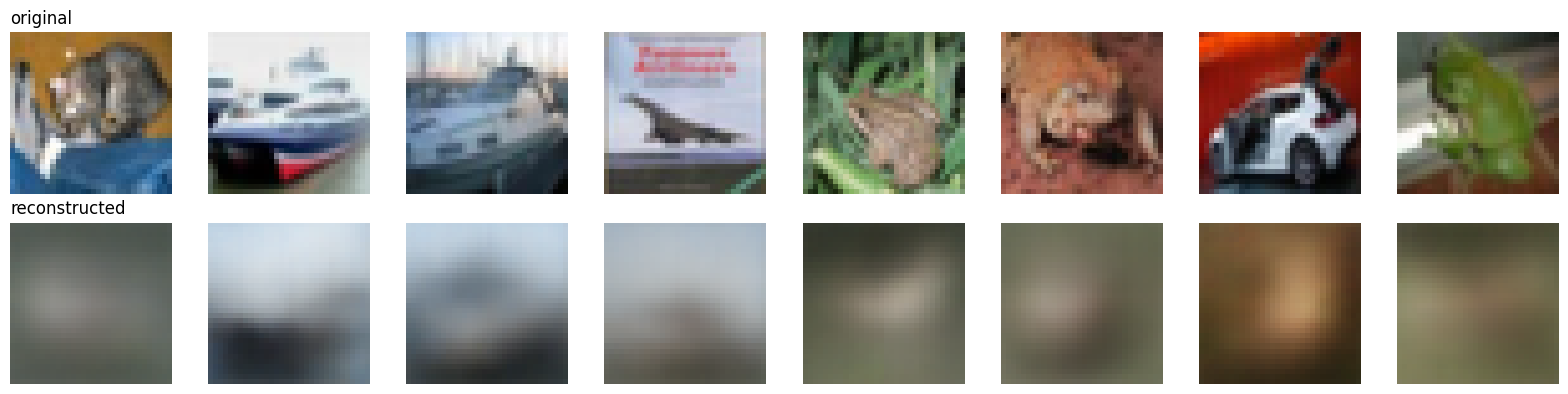

In [18]:
latent_dim = 32  # bumped up again with the deeper network

encoder_inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)   # 32 -> 16
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)                # 16 -> 8
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)               # 8 -> 4
x = layers.Conv2D(256, 3, activation="relu", strides=2, padding="same")(x)               # 4 -> 2
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

# ---------- Decoder ----------
decoder_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(2 * 2 * 256, activation="relu")(decoder_inputs)
x = layers.Reshape((2, 2, 256))(x)
x = layers.Conv2DTranspose(256, 3, activation="relu", strides=2, padding="same")(x)  # 2 -> 4
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)  # 4 -> 8
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)   # 8 -> 16
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)   # 16 -> 32
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")
decoder.summary()

# ---------- VAE model ----------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.mean_squared_error(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# ---------- Data ----------
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# ---------- Train ----------
vae = VAE(encoder, decoder)
_ = vae(X_test_norm[:1])   # build the model
vae.compile(optimizer=keras.optimizers.Adam())

checkpoint_path = "cvae_cifar10_best.weights.h5"
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="loss",
    save_best_only=True,
    verbose=1
)

history = vae.fit(
    X_train_norm,
    epochs=50,
    batch_size=128,
    callbacks=[checkpoint_cb]
)

# ---------- Curves ----------
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='total loss')
plt.plot(history.history['reconstruction_loss'], label='reconstruction loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend()
plt.title('VAE total + reconstruction loss')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['kl_loss'], label='kl loss', color='darkorange')
plt.xlabel('epoch'); plt.ylabel('kl divergence'); plt.legend()
plt.title('KL divergence over training')
plt.show()

print(f"Final total loss: {history.history['loss'][-1]:.4f}")
print(f"Final reconstruction loss: {history.history['reconstruction_loss'][-1]:.4f}")
print(f"Final KL divergence: {history.history['kl_loss'][-1]:.4f}")

# ---------- Reconstructions ----------
vae.load_weights(checkpoint_path)

n = 8
sample_imgs = X_test_norm[:n]
_, _, z = vae.encoder.predict(sample_imgs, verbose=0)
reconstructed = vae.decoder.predict(z, verbose=0)

fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
for i in range(n):
    axes[0, i].imshow(sample_imgs[i]); axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i]); axes[1, i].axis('off')
axes[0, 0].set_title("original", loc='left')
axes[1, 0].set_title("reconstructed", loc='left')
plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 15ms/step


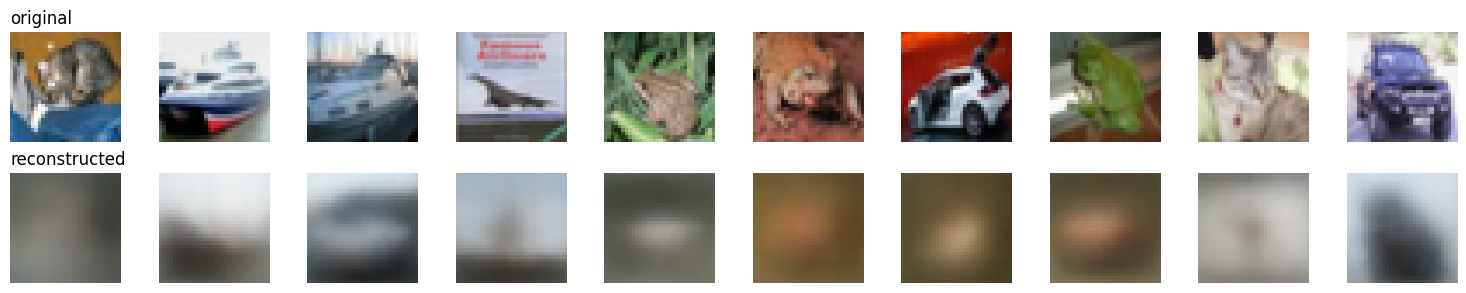

In [19]:
n = 10
sample_imgs = X_test_norm[:n]
_, _, z = vae.encoder.predict(sample_imgs)
reconstructed = vae.decoder.predict(z)

fig, axes = plt.subplots(2, n, figsize=(15, 3))
for i in range(n):
    axes[0, i].imshow(sample_imgs[i])
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i])
    axes[1, i].axis('off')
axes[0, 0].set_title("original", loc='left')
axes[1, 0].set_title("reconstructed", loc='left')
plt.tight_layout()
plt.show() 